Próximos passos: "Responder: posso usar um filtro global ou precisa ser individual?"   

fazer N sinais, embaralhar e 'dar' a divisao dos sinais pra cada wave/canal

P1) Filtro pra cada canal + media dos pesos
1. Fazer um filtro (calc pesos) pra cada canal, e ter tantos filtros qnt canais. edit: feito
2. Aplicar em cada saida para ter tantas reconstruções qnt canais (msm qntd). edit: feito
3. Fazer média dos pesos de todos os canais. edit: feito
4. Aplicar esses pesos em todos os canais

P2) Filtro so com base no canal ideal 
1. Calcular peso so com canal ideal. edit: feito
2. Aplicar esses pesos em todos os canais all_bias_ideias

P3) Comparar resultados com RMSE. edit: feito

P4) Comparativo de erro

peso_especialista_por_canal(all_pesos_ideias[N]) vs peso_global(media_pesos_globais)
=>
sinais estimados
=>

erro (RMSE) sinal_estm_especialista vs sinal_estiamdo_global ambos com o trem d impulso original


desv pad de todos os pesos globais e por (sigma * std) em cada pico. edit: feito


# INIT

In [1]:
# Bibliotecas
from Filtro_LS import filtro_LS0
from Filtro_LS import filtro_LS1
from Filtro_LS import filtro_LS10
from numpy.linalg import pinv as inversa
from Funcoes_auxiliares import *
import os
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import Eq
from sympy import fraction
from sympy.abc import s
from scipy import signal
import random
from numpy import convolve as np_conv
from scipy.signal import convolve as scipy_conv
from pandas import DataFrame

# from datetime import datetime
# from scipy.stats import pearsonr
# from matplotlib.patches import Ellipse
# from Gerador_de_Sinais_copy import *
# from Gerador_de_Sinais import main as sinais_shaper
# from Gerador_de_Sinais import original_signal_generator

In [ ]:
# Gerador/Simulador do sinal registrado pelos sensores #
def original_signal_generator(
    num_amostras_leitura: int,
    position_percentage: float = 0.2,
    media_energia_cintilador: int = 30,
    seed: int | None = None,
):
    """
    position_percentage = 20 a 30 % de num_amostras_leitura
    """
    rng = np.random.default_rng(seed)

    signal = np.zeros(num_amostras_leitura)

    # Sortear indices de signal
    position = int(position_percentage * num_amostras_leitura)

    indx = rng.permutation(len(signal))[:position]
    signal[indx] = rng.exponential(media_energia_cintilador, size=len(indx)).astype(int)

    "Forma antes d mudar para usar o seed"
    # As posições
    # indx = np.random.permutation(len(signal))[:position]
    # As posições com as devidas energias
    # signal[indx] = np.random.exponential(
    #     media_energia_cintilador, size=len(indx)
    # ).astype(int)

    return signal


# Shaper Simulator
def CKTs_parameters():

    ## Definition of constants ##
    tau_1, tau_2, Vo, Vi = sp.symbols("tau_1 tau_2 Vo Vi")
    CC0, C1, C2, C3 = sp.symbols("CC0 C1 C2 C3")
    RL = sp.symbols("RL")
    L1, L2, L3 = sp.symbols("L1 L2 L3")
    I1, I2, I3, I4 = sp.symbols("I1 I2 I3 I4")

    # Ckt components in order
    Cord = [CC0, C1, C2, C3, L1, L2, L3, RL]  # , tau_1, tau_2]

    # Nominal values (old values) of Cord elements in order
    Cval = [
        100e-9,  # CC0
        120e-12,  # Ca = C1
        130e-12,  # Cb = C3 + C2
        83e-12,  # Cc = C5 + C4
        2.48e-6,  # La = L1 + L2
        1.6e-6,  # Lb = L3 + L4
        0.78e-6,  # Lc = L5 + L6
        138.8338,  # RL = (R1 + R2) //  R3
        # 3.1046e-09,  # tau_2
        # 6.5798e-09,  # tau_1
    ]
    tau_1, tau_2 = 3.1046e-09, 6.5798e-09

    # Ckt equations
    eqn1 = Eq(I1 / (CC0 * s) + (I1 - I2) / (C1 * s), Vi)
    eqn2 = Eq((I2 - I3) / (C2 * s) - (I1 - I2) / (C1 * s) + L1 * s * I2, 0)
    eqn3 = Eq((I3 - I4) / (C3 * s) - (I2 - I3) / (C2 * s) + L2 * s * I3, 0)
    eqn4 = Eq(I4 * RL - (I3 - I4) / (C3 * s) + L3 * s * I4, 0)
    eqn5 = Eq(I4 * RL, Vo)

    eqns = [eqn1, eqn2, eqn3, eqn4, eqn5]

    # Solver
    Sol = sp.solve(eqns, (I1, I2, I3, I4, Vo))
    si6 = Sol[I4]

    # PMT
    PMT = (1 / tau_1 - 1 / tau_2) / (
        s**2 + (1 / tau_1 + 1 / tau_2) * s + 1 / tau_1 / tau_2
    )

    # I_out without V_in
    h = RL * si6 / Vi

    # Final transfer function
    H1 = PMT * h

    return H1, Cord, Cval


# gerador de pulsos/ondas
def MC_iteration(
    iterations,
    erro,
    components,
    nominal_values,
    FT,
    t,
    seed: int | None = None,
):
    """
    iter = 0 represents pure/error-free signal value
    MonteCarlo[0] = actual/error-free signal value

    FT: Transfer Function
    t1: time vector
    iterations: int
        number of iterations
    erro: percentage error of circuit components
    nominal_values: nominal values of circuit components

     seed: int | None
        Semente opcional para reprodutibilidade.
    """
    # print("Monte Carlo iteration")

    # Store all the poles of the iterations
    all_poles = []

    # Store the values ​​with error of each iteration
    MonteCarlo = []

    # Store all the FPs added of each iteration # list of all the graphs added with errors
    y_out = []

    # Helper to store the values ​​of y
    y1 = []

    # Seed para reprodutibilidade
    rng = random.Random(seed)

    for iter in range(iterations):

        # Random values; # error range; maximum error from -e% to +e%
        xa = []  # FP function of the summed iteration
        new_Cval = []  # List of components with changed values

        # Changing element values ​​without changing tau1 and tau2
        new_Cval = [
            (
                value * (rng.gauss(0, erro[idx])) + value
                if iter != 0 and idx < len(nominal_values) - 2
                else value
            )
            for idx, value in enumerate(nominal_values)
        ]

        # Saving component variations
        MonteCarlo.append(new_Cval[:-2])

        H = FT
        for variavel, v in zip(components, new_Cval):
            H = H.subs(variavel, v)

        # Separating numerator from denominator
        N_H, D_H = fraction(H)

        """RESIDUOS E POLOS"""

        coefs_num = []  # reset variable
        coefs_den = []  # reset variable

        coefs_num = sp.Poly(N_H, s).all_coeffs()  # get coefs
        coefs_den = sp.Poly(D_H, s).all_coeffs()  # get coefs

        # Frações parciais
        residuos, polos, b0 = [], [], []
        residuos, polos, b0 = signal.residue(coefs_num, coefs_den)

        # Saving all poles
        all_poles.append(polos)

        # Residual correction (removing the img part 0j from the real residuals)
        for polo1, residuo1 in zip(polos, residuos):
            if polo1.imag == 0:
                residuo1 = residuo1.real

        """LAPLACE INVERSA E GRAFICOS"""

        for enum, (polo, residuo) in enumerate(zip(polos, residuos)):

            # Check if the imaginary part is zero
            if polo.imag == 0:
                "EXPONENCIAIS"

                # Removing the img part (0j) of the real residues
                A = residuo.real
                d = polo.real
                x = A * np.exp(d * t)

                xa.append(x)

            else:
                "SENOS E COSSENOS"

                pol_1 = polos[enum - 1]  # conjugate

                if polo != pol_1 and polo != np.conjugate(pol_1):

                    a1 = polo.real
                    b1 = abs(polo.imag)

                    Mod = abs(residuos[enum])  # Modulo
                    fase = np.angle(residuos[enum])  # fase in rad

                    # FP term
                    x = 2 * Mod * np.exp(a1 * t) * np.cos(b1 * t + fase)

                    xa.append(x)

        "SUMMING THE TERMS"

        if iter != 0:
            y1 = sum(xa).real / maxs
            y_out.append(y1)

        else:
            sinal0 = sum(xa).real
            maxs = np.max(np.abs(sinal0))
            y1 = sinal0 / maxs  # largest module/ normalize
            y_out.append(y1)

    return y_out


# Chama a função degerador de ondas da devida maneira
def wave_former_main(
    num_canais: int,
    qntd_amostras: int,
    CKT_parameters: Callable | None,
    CKT_simulator: Callable | None,
    noise: int | float | list | np.ndarray = 0,
    parameters: dict | None = None,
    Seed: int | None = None,
):
    """# DOCSTRING REQUER ATUALIZAÇÃO

    Função para gerar a matriz de convolução de um circuito.
    A matriz resultate é qudrada (amostras_leitura x amostras_leitura).


    Parametros:
    -----------
    amostras_leitura: quantidade de amostras na leitura

    noise: erro/ruído associado a leitura do sinal para cada elemento do circuito. No caso d ser lista/array, deve ter o mesmo len() que Componentes, de CKT_parameters.

    CKT_parameters: parametros do circuito a ser simulado. Deve, obrigatoriamente, retornar 3 objetos/variaveis, nesta ordem:
        1. Função de transferência do circuito com as variaveis ainda a serem substituidas (funçao literal com o sympy),
        2. Componentes: Lista de variaveis do circuito como objeto sympy.symbols
        3. Valor_componentes: Lista dos valores dos componentes do circuito respeitando a ordem da variavel Componentes.

    parameters: Dicionario com as variáveis a serem desempacotadas para a função CKT_simulator().

    CKT_simulator: Função que faz a simulção do circuito.

    Return:
    -------
    Retorna os resultados da simulação do circuito de CKT_simulator().
    """

    # Parametros do CKT #

    TF, component, component_values = CKT_parameters()  # type: ignore[operator]

    # Parametros do gerador das formas de onda #
    if parameters is None:
        parametros_MC = {
            "iterations": num_canais,
            "t": np.arange(0, qntd_amostras) * 25 * 10**-9,
            "FT": TF,  # literal
            "erro": noise,  # Erro de cada elemento do circuito
            "components": component,
            "nominal_values": component_values,
            "seed": Seed,
        }

    return CKT_simulator(**parametros_MC)  # type: ignore[operator]


# Calcula medias de um dicionario com tuplas em values
# Calcula média para cada canal
def media_metricas_dict(dicio):
    medias_metricas = {
        canal: tuple(np.mean(v) for v in zip(*valores))
        for canal, valores in dicio.items()
    }
    return medias_metricas


# Calcula media global; devolve um numero (Um pra RMSE e um para MSE)
def media_geral_itens(rmse_dict):
    """
    Calcula a média de todos os primeiros itens e a média de todos os segundos itens
    dos valores (tuplas) no dicionário RMSE_com_peso_medio.

    Args:
        rmse_dict (dict): Dicionário onde cada valor é uma tupla de dois números.

    Returns:
        tuple: (média do primeiro item, média do segundo item)
    """
    # primeiros = [valores[0] for valores in rmse_dict.values()]
    # segundos = [valores[1] for valores in rmse_dict.values()]
    # media_primeiro = np.mean(primeiros)
    # media_segundo = np.mean(segundos)
    # return (media_primeiro, media_segundo)
    all_vals = np.stack(list(rmse_dict.values()))  # Cria um array 2D (n, 2)
    return (np.mean(all_vals[:, 0]), np.mean(all_vals[:, 1]))


# Maiores e menores valores dos RMSE's e MSE's de cada canal
def extremos_tuplas(dicionario):
    """
    Para cada chave do dicionário, retorna:
    - tuplas com maior primeiro ou segundo elemento
    - tuplas com menor primeiro ou segundo elemento

    Se a mesma tupla aparecer em mais de um critério,
    ela é retornada apenas uma vez.
    """
    resultado = {}

    for chave, lista in dicionario.items():
        if not lista:
            resultado[chave] = {"maximos": [], "minimos": []}
            continue

        max_0 = max(lista, key=lambda t: t[0])
        max_1 = max(lista, key=lambda t: t[1])

        min_0 = min(lista, key=lambda t: t[0])
        min_1 = min(lista, key=lambda t: t[1])

        # Remove duplicatas preservando a ordem
        maximos = list(dict.fromkeys([max_0, max_1]))
        minimos = list(dict.fromkeys([min_0, min_1]))

        resultado[chave] = {"maximos": maximos, "minimos": minimos}

    return resultado


# Maiores e menores valores dos RMSE's e MSE's global
def extremos_globais(dicionario):
    """
    Retorna as tuplas extremas de todo o dicionário.

    Saída:
        {
            'maximos': [...],
            'minimos': [...]
        }
    """
    # Junta todas as tuplas em uma única lista
    todas = [tupla for lista in dicionario.values() for tupla in lista]

    if not todas:
        return {"maximos": [], "minimos": []}

    # Máximos
    max_0 = max(todas, key=lambda t: t[0])
    max_1 = max(todas, key=lambda t: t[1])

    # Mínimos
    min_0 = min(todas, key=lambda t: t[0])
    min_1 = min(todas, key=lambda t: t[1])

    # Remove duplicatas preservando ordem
    maximos = list(dict.fromkeys([max_0, max_1]))
    minimos = list(dict.fromkeys([min_0, min_1]))

    return {"maximos": maximos, "minimos": minimos}


#

In [3]:
# Consantes & Variáveis #

"""Estrutura Variáveis
Sinais = {
    "canal_0": # canal com a forma de onda do Shaper ideal
        [conv(sinais_originais[0], waves_por_canal[0])],
        [conv(sinais_originais[1], waves_por_canal[0])],
        [conv(sinais_originais[2], waves_por_canal[0])],
    ],
    "canal_1": [
        [conv(sinais_originais[3], waves_por_canal[1])],
        [conv(sinais_originais[4], waves_por_canal[1])],
        [conv(sinais_originais[5], waves_por_canal[1])],
    ],
    "canal_2": [
        [conv(sinais_originais[6], waves_por_canal[3])],
        [conv(sinais_originais[7], waves_por_canal[3])],
        [conv(sinais_originais[8], waves_por_canal[3])],
    ],
}
"""

qntd_canais = 100  # qntd de listas
amostras_por_leitura = 1000  # tamanho da lista
qntd_leitura_por_canal = 475  # usado para as leituras e medias
seed = 345  # fator aleatorio reprodutivel

In [4]:
# Ondas/resp aos pulsos gerados

ckt_parameters_error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100

# cada linha é um canal
waves_por_canal = np.asarray(  # waves_por_canal[0] = sinal sem variação dos componentes
    wave_former_main(
        num_canais=qntd_canais,
        qntd_amostras=amostras_por_leitura,
        noise=ckt_parameters_error,
        CKT_parameters=CKTs_parameters,
        CKT_simulator=MC_iteration,
        Seed=seed,
    )
)

In [ ]:
# print(f"{len(sinais_originais), len(sinais_originais[0])}")
print(f"{len(waves_por_canal), len(waves_por_canal[0])}")
"quantidade de canal e amostras em cada canal"

In [ ]:
# Estatisticas

Estatisticas_por_canal = DataFrame(waves_por_canal).T.describe()
Estatisticas_por_canal

# Filtros


In [ ]:
# Filtro
def LS_filter(
    sinal_desejado: np.ndarray,
    readout: np.ndarray,
    ordem_filter: int = 7,
    delay: int = 2,
):
    """
    Versão 1 do Filtro LS para deconvolução do Circuito Shaper com o sinal de entrada.
    Método: Pseudo Inversa de Moore-Penrose
    """
    # Qantidade de sinaiss
    qntd_leitura = len(readout)

    # Matriz de Observação #
    matriz_obs = matriz_observacao(readout, ordem_filtro=ordem_filter)

    # Adiciona coluna de 1 para aprender o bias
    matriz_obs = np.column_stack([matriz_obs, np.ones(matriz_obs.shape[0])])

    # Calculo peso #
    limite_filtro = matriz_obs.shape[0]  # qntd_leitura - ordem_filter + 1 + delay

    # Pesos via pseudo-inversa
    aux_peso = (
        inversa(matriz_obs.T @ matriz_obs)
        @ matriz_obs.T
        @ sinal_desejado[delay : delay + limite_filtro]
    )

    peso = np.flipud(aux_peso[:-1])  # -1 para retirar o bias
    bias = aux_peso[-1]

    # Sinal Estimado/Recuperado #
    sinal_estimado = np.zeros(qntd_leitura)

    # Parte adaptativa do filtro
    len_sinal_estimado = qntd_leitura - ordem_filter + 1

    for i in range(len_sinal_estimado):
        sinal_estimado[i] = np.dot(readout[i : i + ordem_filter], peso) + bias

    # Retira os valores menores que 0
    sinal_estimado = np.clip(sinal_estimado, 0, None)

    return sinal_estimado, peso, bias

In [6]:
# Aplicando os pesos e bias já calculados em um sinal novo #
def sinal_estimado_com_pesos_ja_calculados(
    pesos, bias, Readout, ordem_filtro: int = 7, min_clip: None | float = None
):
    """
    Aplica pesos e bias previamente calculados em uma entrada nova.

    O obetivo é verificar a capacidade de generalizaçao do filtro.
    """

    # aplicando filtro #
    qntd_leitura = len(Readout)

    # Sinal Estimado/Recuperado
    sinal_estimado_2 = np.zeros(qntd_leitura, dtype=float)

    # Tamanho do sinal estimado
    len_sinal_estimado = qntd_leitura - ordem_filtro + 1

    # Parte adaptativa do filtro
    for i in range(len_sinal_estimado):
        sinal_estimado_2[i] = np.dot(Readout[i : i + ordem_filtro], pesos) + bias

    if min_clip is not None:
        sinal_estimado_2 = np.clip(sinal_estimado_2, min_clip, None)

    return sinal_estimado_2

# Estruturando variáveis

In [ ]:
"Estrutura da variavel"

# Sinais = {
#     "canal_0": # canal com a forma de onda do Shaper ideal
#         [conv(sinais_originais[0], waves_por_canal[0])],
#         [conv(sinais_originais[1], waves_por_canal[0])],
#         [conv(sinais_originais[2], waves_por_canal[0])],
#     ],
#     "canal_1": [
#         [conv(sinais_originais[3], waves_por_canal[1])],
#         [conv(sinais_originais[4], waves_por_canal[1])],
#         [conv(sinais_originais[5], waves_por_canal[1])],
#     ],
#     "canal_2": [
#         [conv(sinais_originais[6], waves_por_canal[3])],
#         [conv(sinais_originais[7], waves_por_canal[3])],
#         [conv(sinais_originais[8], waves_por_canal[3])],
#     ],
# }


# Logica de corespondencia wave x sinal_orig

# correspondencia_covolucao = {
#     "canal_1": [
#         [wave[0], matriz_indices[0][0]],
#         [wave[0], matriz_indices[0][1]],
#         [wave[0], matriz_indices[0][2]],
#     ],
# }

In [7]:
# Sinais Originais #
s_originais = {}  # s_originais
count = 0  # para modificar os sinais entre si

for canais in range(qntd_canais):
    s_originais[f"canal_{canais}"] = []

    for amostra in range(qntd_leitura_por_canal):
        s_originais[f"canal_{canais}"].append(
            original_signal_generator(amostras_por_leitura, seed=seed + count)
        )
        count += 3

In [ ]:
s_originais["canal_0"][0] == s_originais["canal_0"][1]

In [8]:
# Readouts #


# aqui eu jogo fora qse metade final da convoluçao q vem se aproximando de zero

# lim_leitura = int(amostras_por_leitura * 1.1)
# for (canal, amostras), wave in zip(s_originais.items(), waves_por_canal):
#     leituras[canal] = [
#         np_conv(amostra, wave, mode="full")[:lim_leitura] for amostra in amostras
#     ]

leituras = {}
for (canal, amostras), wave in zip(s_originais.items(), waves_por_canal):
    leituras[canal] = [np_conv(amostra, wave, mode="full") for amostra in amostras]

In [9]:
# Especialistas: Sinais Reconstruidos, Pesos e Bias #

"""
estrutura sinais

sinais = {
    canal_0: [ [sinais_01],[sinais_02] ], # canal ideal
    canal_1: [ [sinais_11],[sinais_01] ], # canal com avarias
}


"""

ordem_filtro = 7

sinais_reconstruidos_pesos_especialistas = {}
dicio_RMSE_pesos_especialistas = {}

all_pesos_globais, all_bias_globais = [], []
all_pesos_ideias, all_bias_ideias = [], []


for (canal, sd), rd in zip(s_originais.items(), leituras.values()):
    sinais_reconstruidos_pesos_especialistas[canal] = []
    dicio_RMSE_pesos_especialistas[canal] = []

    for s_desejado, readout in zip(sd, rd):

        sr, peso, bias = LS_filter(
            sinal_desejado=s_desejado, readout=readout[: len(s_desejado)]
        )

        sinais_reconstruidos_pesos_especialistas[canal].append(sr)

        if canal == "canal_0":
            all_pesos_ideias.append(peso)
            all_bias_ideias.append(bias)

        all_pesos_globais.append(peso)
        all_bias_globais.append(bias)

        dicio_RMSE_pesos_especialistas[canal].append(
            RMSE_e_MAE_por_ordem(s_desejado, sr, ordem_filtro=7)
        )

#

#
Calculo dos pesos globais

In [12]:
# Media dos Pesos e Bias Global

media_pesos_globais = np.mean(all_pesos_globais, axis=0)  # axis=0 -> média por coluna
media_bias_globais = np.mean(all_bias_globais, axis=0)
print(f"{media_pesos_globais = },\n{media_bias_globais = }\n")

print("-" * 100)

# Media dos Pesos e Bias ideias
media_pesos_ideias = np.mean(all_pesos_ideias, axis=0)
media_bias_ideias = np.mean(all_bias_ideias, axis=0)
print(f"\n{media_pesos_ideias = },\n{media_bias_ideias = }\n")

print("-" * 100)

# Desvio padrao
print("Desvio Padrão:")
print("Pesos: ", np.array(all_pesos_globais).std())
print("Bias: ", np.array(all_bias_globais).std())

media_pesos_globais = array([ 0.04781877, -0.2600486 ,  1.09503772, -0.23208515,  0.06551613,
        0.06705083, -0.04774262]),
media_bias_globais = np.float64(3.2925763089744926)

----------------------------------------------------------------------------------------------------

media_pesos_ideias = array([ 0.04816717, -0.26192372,  1.09602485, -0.23278384,  0.06588962,
        0.06727616, -0.0480641 ]),
media_bias_ideias = np.float64(3.2961986961275973)

----------------------------------------------------------------------------------------------------
Desvio Padrão:
Pesos:  0.4242919604217537
Bias:  0.33247529006295484


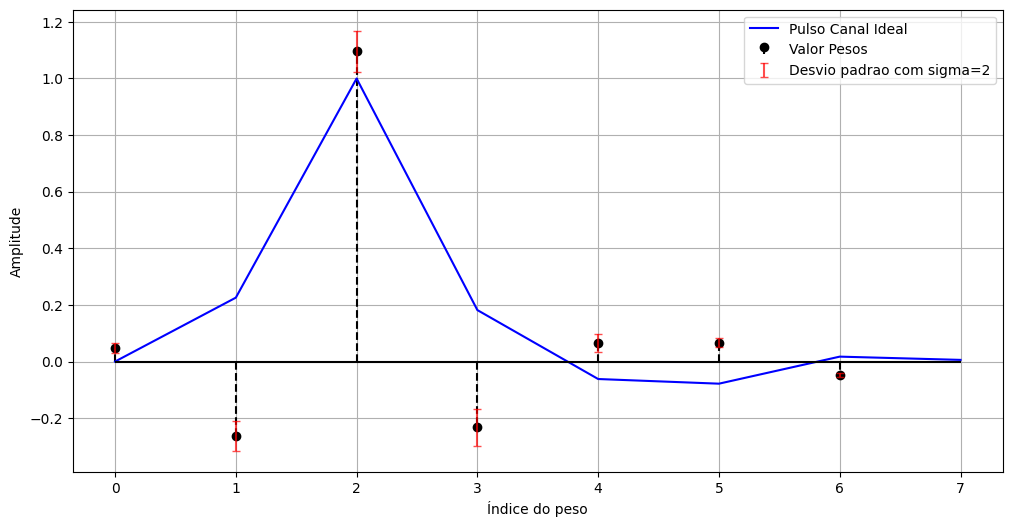

In [13]:
# Plot pesos media_pesos_ideias em um pulso ideal

sigma = 2
x = np.arange(len(media_pesos_ideias))[:8]
des_pad_cada_peso = np.std(all_pesos_globais, axis=0)

plt.figure(figsize=(12, 6))
# plt.stem(x, media_pesos_ideias, basefmt=" ", linefmt="C0-", markerfmt="C0o")
plt.stem(x, media_pesos_ideias, linefmt="ko--", markerfmt="o", basefmt=" ")
plt.errorbar(
    x,
    media_pesos_ideias,
    yerr=des_pad_cada_peso * sigma,
    fmt="none",
    ecolor="r",
    capsize=3,
    alpha=0.7,
)

plt.plot(waves_por_canal[0][:8], color="b")
plt.grid()
plt.xlabel("Índice do peso")
plt.ylabel("Amplitude")
plt.legend(["Pulso Canal Ideal", "Valor Pesos", f"Desvio padrao com sigma={sigma}"])
plt.hlines(0, 0, 7, "black")

In [14]:
# peso_especialista_por_canal vs peso_global

sinal_recon_pesos_prev_calc = {}
dicio_RMSE_pesos_prev_calc = {}

for (canal, all_readouts), all_so in zip(leituras.items(), s_originais.values()):

    sinal_recon_pesos_prev_calc[canal] = []
    dicio_RMSE_pesos_prev_calc[canal] = []

    for readout, original in zip(all_readouts, all_so):
        s_estimado = sinal_estimado_com_pesos_ja_calculados(
            pesos=media_pesos_globais,
            bias=media_bias_globais,
            Readout=readout,
            ordem_filtro=7,
            min_clip=0,
        )

    sinal_recon_pesos_prev_calc[canal].append(s_estimado)

    dicio_RMSE_pesos_prev_calc[canal].append(
        RMSE_e_MAE_por_ordem(original, s_estimado, ordem_filtro=7)
    )
# # cria a media de cada canal
# RMSE_com_peso_medio = media_metricas_dict(dicio_RMSE_pesos_prev_calc)

# # cria media global
# media_da_media = media_geral_itens(RMSE_com_peso_medio)
# media_da_media

In [ ]:
# pesos e bias prev calc s_o novo
# # Aplicando os pesos e bias já calculados em um sinal novo #

# s_estimados_pesos_prev_calc = {}
# dicio_RMSE_pesos_prev_calc = {}

# for (canal, rd), so in zip(leituras.items(), s_originais.values()):

#     s_estimados_pesos_prev_calc[canal] = []
#     dicio_RMSE_pesos_prev_calc[canal] = []

#     for readout, original in zip(rd, so):
#         if canal == "canal_0":
#             s_estimado = sinal_estimado_com_pesos_ja_calculados(
#                 pesos=media_pesos_ideias,
#                 bias=media_bias_ideias,
#                 Readout=readout,
#                 ordem_filtro=7,
#                 min_clip=0,
#             )

#         else:
#             s_estimado = sinal_estimado_com_pesos_ja_calculados(
#                 pesos=media_pesos_globais,
#                 bias=media_bias_globais,
#                 Readout=readout,
#                 ordem_filtro=7,
#                 min_clip=0,
#             )

#         s_estimados_pesos_prev_calc[canal].append(s_estimado)

#         dicio_RMSE_pesos_prev_calc[canal].append(
#             RMSE_e_MAE_por_ordem(original, s_estimado, ordem_filtro=7)
#         )
# # cria a media de cada canal
# RMSE_com_peso_medio = media_metricas_dict(dicio_RMSE_pesos_prev_calc)

# # cria media global
# media_da_media = media_geral_itens(RMSE_com_peso_medio)
# media_da_media

In [27]:
# extremos_especialista_por_canal = extremos_tuplas(dicio_RMSE_pesos_especialistas)
# extremos_globais_por_canal = extremos_tuplas(dicio_RMSE_pesos_prev_calc)

extremo_especialista_global = extremos_globais(dicio_RMSE_pesos_especialistas)
extremo_globais_globais = extremos_globais(dicio_RMSE_pesos_prev_calc)

print("Resultados Especialista:")
print(f"Dupla de erro com Maior RMSE: {extremo_especialista_global['maximos'][0]}")
print(f"Dupla de erro com Maior MSE: {extremo_especialista_global['maximos'][1]}\n")
print(f"Dupla de erro com Menor RMSE: {extremo_especialista_global['maximos'][0]}")
print(f"Dupla de erro com Menor MSE: {extremo_especialista_global['maximos'][0]}\n")
print("-" * 100)
print("\nResultados Globais:")
print(f"Dupla de erro com Maior RMSE: {extremo_globais_globais['maximos'][0]}")
print(f"Dupla de erro com Maior MSE: {extremo_globais_globais['maximos'][1]}\n")
print(f"Dupla de erro com Menor RMSE: {extremo_globais_globais['maximos'][0]}")
print(f"Dupla de erro com Menor MSE: {extremo_globais_globais['maximos'][0]}")

Resultados Especialista:
Dupla de erro com Maior RMSE: (np.float64(3.1211018567385085), np.float64(1.7043551826949073))
Dupla de erro com Maior MSE: (np.float64(3.0553156067690463), np.float64(1.807883465940058))

Dupla de erro com Menor RMSE: (np.float64(3.1211018567385085), np.float64(1.7043551826949073))
Dupla de erro com Menor MSE: (np.float64(3.1211018567385085), np.float64(1.7043551826949073))

----------------------------------------------------------------------------------------------------

Resultados Globais:
Dupla de erro com Maior RMSE: (np.float64(2.675120606075933), np.float64(1.2359935931301778))
Dupla de erro com Maior MSE: (np.float64(2.6105540241221985), np.float64(1.65488950982373))

Dupla de erro com Menor RMSE: (np.float64(2.675120606075933), np.float64(1.2359935931301778))
Dupla de erro com Menor MSE: (np.float64(2.675120606075933), np.float64(1.2359935931301778))


In [ ]:
# Detecção
ideal = leituras["canal_0"][1]
ideal = ideal[:81]
ideal = np.clip(ideal, 0, None)

lista = ideal  # [:15]
labels = {
    "label_zerado": "parado",
    "label_descendo": "descendo",
    "label_subindo": "subindo",
    "label_pico": "pico",
}


def comparacao(
    atual: int | float,
    anterior: int | float,
    futuro: int | float,
    label_zerado: str = "parado",
    label_descendo: str = "descendo",
    label_subindo: str = "subindo",
    label_pico: str = "pico",
):
    if atual == anterior:
        return label_zerado

    elif anterior < atual and futuro < atual:  # ambos menores
        return label_pico

    elif anterior > atual:
        return label_descendo

    elif anterior < atual:
        return label_subindo


def classifier(lista: list, **Kargs):
    resultado = []
    for enum, item in enumerate(lista):
        try:
            item_futuro = lista[enum + 1]
        except IndexError:
            item_futuro = np.inf

        if enum == 0:
            aux = comparacao(item_futuro, item, lista[enum + 2], **Kargs)
            resultado.append(aux)
            item_anterior = item
            continue

        aux = comparacao(item, item_anterior, item_futuro, **Kargs)
        resultado.append(aux)
        item_anterior = item

    return resultado


result = classifier(lista, **labels)

mask = []
for r, i in zip(result, lista):
    if r == "pico":
        mask.append(i)
    else:
        mask.append(0)

plt.xlabel("Amostras")
plt.ylabel("amplitude")
plt.stem(mask)
plt.plot(s_originais["canal_0"][1][:80])
plt.grid()

In [ ]:
plt.plot(s_originais["canal_0"][1][:80])

In [ ]:
# print(len(mask) == len(lista))
plt.xlabel("Amostras")
plt.ylabel("amplitude")
plt.stem(mask[2:])
plt.plot(s_originais["canal_0"][1][:80], color="orange")
plt.grid()

# Testes

In [ ]:
# # tentativa 1

# # Gerador de sinais #
# sinais_originais = []

# for canal in range(qntd_canais * qntd_leitura_por_canal):
#     s_o = original_signal_generator(amostras_por_leitura, seed=seed + canal)
#     sinais_originais.append(s_o)


# # sinais_originais[1], plt.plot(sinais_originais[1])
# print(len(sinais_originais), len(sinais_originais[1]))
# "quantidade de sinais de entrada e quantidade de amostras de cada sinal de entrada"

# # Canais de leituras #

# # lista de indice para cada linha d sinal_original permutado
# indices_permutados = np.random.permutation(len(sinais_originais))

# # len(sinais_originais) == len(qntd_canais * qntd_leitura_por_canal)
# divisao = int(len(sinais_originais) / qntd_canais)  # sempre será divisível

# # cada linha da matriz representa a linha de s_original q sera convoluido com aquela forma de onda
# matriz_indices = indices_permutados.reshape(qntd_canais, divisao)

# leituras_canais = {}
# correspondencia_covolucao = {}
# lim_leitura = int(amostras_por_leitura * 1.1)

# for enum, wave in enumerate(waves_por_canal):
#     matriz_leitura = []
#     # print('          ',enum)

#     # permutaçao organizada em ordem crescente
#     matriz_permutada_organizada = sorted(matriz_indices[enum])

#     # { canal: indices do sinal original usados }
#     correspondencia_covolucao[f"canal_{enum}"] = matriz_permutada_organizada

#     # for indx in matriz_indices[enum]:
#     for indx in matriz_permutada_organizada:
#         # print(indx)
#         aux_matriz_leitura = np_conv(sinais_originais[indx], wave, mode="full")
#         # matriz_leitura.append(aux_matriz_leitura)
#         matriz_leitura.append(aux_matriz_leitura[:lim_leitura])

#     leituras_canais[f"canal_{enum}"] = matriz_leitura

# # Sinais reconstruidos #

# # sinal_reconstruido, peso, bias = LS_filter(
# #     sinal_desejado=sinais_originais[1],
# #     readout=leituras_canais["canal_0"][2][:79],
# #     ordem_filter=ordem_filtro0,
# # delay=2,
# # )
# # plot_estimado_x_original(
# #     sinais_originais[1],
# #     estimado=sinal_reconstruido,
# #     ordem=ordem_filtro0,
# #     title="Original x filtro_LS0",
# # )

# ordem_filtro0 = 7
# sinais_reconstruidos, all_pesos, all_bias = [], [], []
# lim_filter = len(aux_matriz_leitura) - amostras_por_leitura + 1
# # print(lim_filter)
# for canal, indx in correspondencia_covolucao.items():
#     # print(canal, [int(x) for x in indx])
#     for enum, ind in enumerate(indx):
#         # print(enum)
#         s_reconstruido, peso, bias = LS_filter(
#             sinais_originais[ind],
#             readout=leituras_canais[canal][enum][:lim_filter],
#         )
#         peso = np.append(peso, bias)

#         sinais_reconstruidos.append(s_reconstruido)
#         all_pesos.append(peso)
#         # all_bias.append(bias)

# media_pesos = np.mean(all_pesos, axis=0)
# media_bias1 = media_pesos[-1]

# # media_bias2 = np.mean(all_bias, axis=0)  #  = np.mean(all_bias)
# # media_bias1 == media_bias2 = true, soq com qntd de casas decimais diferentes
# # Aplicar peso e bias nos sinais reconstruidos e comparar com os devidos sinais originais

# # Correspondencia para o plot # incompleto
# for canal, coor in correspondencia_covolucao.items():
#     for enum, sincro in enumerate(coor):
#         print(sincro)
#         # sinais_originais[sincro]
#         print(leituras_canais[canal][enum])
#         break

In [ ]:
leituras_canais = {}
# leituras_canais = {
#     f"canal_{canal+1}":
#         conv(sinais_originais[sinal], waves_por_canal[canal])
#         for sinal in range(len(sinais_originais))
#     for canal in range(qntd_canais)
# }

for canal in range(qntd_canais):
    leituras_canais[f"canal_{canal}"] = []
    for sinal in range(len(sinais_originais)):
        aux = conv(sinais_originais[sinal], waves_por_canal[canal])
        leituras_canais[f"canal_{canal}"].append(aux)

In [ ]:
leituras_canais = {}
leituras_canais = {
    "canal_1": [
        conv(sinais_originais[0], waves_por_canal[0]),
        conv(sinais_originais[1], waves_por_canal[0]),
        conv(sinais_originais[2], waves_por_canal[0]),
    ],
    "canal_2": [
        conv(sinais_originais[0], waves_por_canal[1]),
        conv(sinais_originais[1], waves_por_canal[1]),
        conv(sinais_originais[2], waves_por_canal[1]),
    ],
    "canal_3": [
        conv(sinais_originais[0], waves_por_canal[2]),
        conv(sinais_originais[1], waves_por_canal[2]),
        conv(sinais_originais[2], waves_por_canal[2]),
    ],
}

In [ ]:
len(leituras_canais["canal_1"])

In [ ]:
conv(sinais_originais[0], waves_por_canal[0])

In [ ]:
import numpy as np

mtz3 = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
    [13, 14, 15],
    [16, 17, 18],
]
# 1. Permutar um array existente
# [10, 20, 30, 40, 50]
arr = np.array(mtz3)
embaralhado3 = np.random.permutation(arr)
print(embaralhado3)  # Ex: [30 10 50 20 40]
print("\n", arr)  # Original permanece: [10 20 30 40 50]

# 2. Gerar uma permutação de inteiros (0 a n-1)
sequencia = np.random.permutation(5)
# print(sequencia)  # Ex: [2 0 4 1 3]

In [ ]:
divisao3 = int(len(embaralhado3) / qntd_canais)
terco1 = embaralhado3[:divisao3]
terco2 = embaralhado3[divisao3 : divisao3 * 2]
terco3 = embaralhado3[divisao3 * 2 :]
terco3

In [ ]:
mtz = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
    [13, 14, 15],
    [16, 17, 18],
    [19, 20, 21],
    [22, 23, 24],
    [25, 26, 27],
]

# matriz = np.arange(36).reshape(12, 3)
matriz = np.arange(4 * 3 * 3).reshape(12, 3)
indx_matriz_embaralhada = np.random.permutation(len(matriz))

div4 = int(len(matriz) / 4)
q1 = matriz[:div4]
q2 = matriz[div4 : div4 * 2]
q3 = matriz[div4 * 2 : div4 * 3]
q4 = matriz[div4 * 3 :]
q4

In [ ]:
indices = [0, 1, 2]
# np.random.permutation(len(sinais_originais))
embaralhado3[indices]

In [ ]:
print(indx_matriz_embaralhada)

indices = indx_matriz_embaralhada.reshape(4, div4)
indices

In [ ]:
waves_por_canal, waves_por_canal[0]

In [ ]:
# lista de indice para cada linha d sinal_original permutado
indices_permutados = np.random.permutation(len(sinais_originais))

# len(sinais_originais) == len(qntd_canais * qntd_leitura_por_canal)
divisao = int(len(sinais_originais) / qntd_canais)  # sempre será divisível

matriz_indices = indices_permutados.reshape(qntd_canais, divisao)

In [ ]:
"""modelo:
y = x * h + n

y = sinal_estimado
x = sinal_original
h = canais
n = ruido
gi = filtro
x_hat = (x * hi) * gi
"""

x = sinais_originais[3]
yi = []
for i in range(qntd_canais):
    hi = waves_por_canal[i]
    yi.append(np_conv(x, hi, mode="full"))
# len(yi) == 149

In [ ]:
plt.figure(figsize=(12, 7))
plt.xlim(-5, 80)
plt.plot(waves_por_canal[2])
plt.plot(yi[1][2:])
plt.plot(x[:-2])
plt.grid()
plt.legend(["wave", "convoluido", "entrada"])

In [ ]:
"""
qntd_canais = 3
qntd_leitura_por_canal = 4
amostras_por_leitura = 75
seed = 345


for canal in range(qntd_canais * qntd_leitura_por_canal):
    s_o = original_signal_generator(amostras_por_leitura, seed=seed + canal)
    sinais_originais.append(s_o)

"""

# s_originais = {
#     "canal_0": [[1], [2], [3], [4]],
#     "canal_1": [[1], [2], [3], [4]],
#     "canal_2": [[1], [2], [3], [4]],
# }


s_originais = {}  # s_originais
for canais in range(qntd_canais):
    s_originais[f"canal_{canais}"] = []
    for amostra in range(qntd_leitura_por_canal):
        s_originais[f"canal_{canais}"].append(
            original_signal_generator(amostras_por_leitura, seed=seed + canais)
        )

keys = s_originais.keys()

leituras = {}

# aqui eu jogo fora metade final da convoluçao q vem se aproximando de zero
lim_leitura = int(amostras_por_leitura * 1.1)

for (canal, amostras), wave in zip(s_originais.items(), waves_por_canal):
    leituras[canal] = [
        np_conv(amostra, wave, mode="full")[:lim_leitura] for amostra in amostras
    ]

In [ ]:
ideal = leituras["canal_0"][1]
ideal = ideal[:81]
ideal = np.clip(ideal, 0, None)

pedaco = ideal[:15]

plt.figure(figsize=(12, 8))
plt.grid()
plt.plot(ideal, color="blue")
# plt.plot(estimado, color="darkorange")
# plt.legend(["Original", "Estimado"])
plt.show()

In [ ]:
pedaco = ideal[:15]
pedaco

In [ ]:
plt.figure(figsize=(12, 8))
plt.grid()
plt.plot(pedaco, color="blue")
plt.show()

In [ ]:
lista = ideal[:15]
labels = {
    "label_zerado": "parado",
    "label_descendo": "descendo",
    "label_subindo": "subindo",
    "label_pico": "pico",
}


def comparacao(
    atual: int | float,
    anterior: int | float,
    futuro: int | float,
    label_zerado: str = "parado",
    label_descendo: str = "descendo",
    label_subindo: str = "subindo",
    label_pico: str = "pico",
):
    if atual == anterior:
        return label_zerado

    elif anterior < atual and futuro < atual:  # ambos menores
        return label_pico

    elif anterior > atual:
        return label_descendo

    elif anterior < atual:
        return label_subindo


def classifier(lista: list, **Kargs):
    resultado = []
    for enum, item in enumerate(lista):
        try:
            item_futuro = lista[enum + 1]
        except IndexError:
            item_futuro = np.inf

        if enum == 0:
            aux = comparacao(item_futuro, item, lista[enum + 2], **Kargs)
            resultado.append(aux)
            item_anterior = item
            continue

        aux = comparacao(item, item_anterior, item_futuro, **Kargs)
        resultado.append(aux)
        item_anterior = item

    return resultado


result = classifier(lista, **labels)

mask = []
for r, i in zip(result, lista):
    if r == "pico":
        mask.append(i)
    else:
        mask.append(0)

print(len(mask) == len(lista))
plt.xlabel("Amostras")
plt.ylabel("amplitude")
plt.stem(mask)
plt.grid()

In [ ]:
result

In [ ]:
mask = []
for r, i in zip(result, lista):
    if r == "pico":
        mask.append(i)
    else:
        mask.append(0)

print(len(mask) == len(lista))
plt.xlabel("Amostras")
plt.ylabel("amplitude")
plt.stem(mask)
plt.grid()

In [ ]:
n = np.arange(0, 20)
x = np.zeros_like(n, dtype=float)
x[5] = 1
x[12] = 0.6

plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("amplitude")
plt.show()


# t = np.array([2, 7, 11])
# a = np.array([1.0, 0.5, 0.8])

# plt.vlines(t, 0, a)
# plt.scatter(t, a)  # ponto no topo (opcional)
# plt.show()

In [ ]:
# for e, i in enumerate(lista):
#     print(f"{e} - {i}")

plt.plot(lista)
plt.grid()

In [ ]:
def classificar_lista_por_ranges(
    valores,
    ranges,
    pico_min,
    label_parado="parado",
    label_subindo="subindo",
    label_pico="pico",
    label_descendo="descendo",
):
    """
    Substitui cada valor por um rotulo baseado em ranges.

    Regras:
    - Se o valor estiver no range de 'pico' e for >= pico_min, rotula como 'pico'.
    - Se estiver no range de 'pico' mas < pico_min, rotula como 'parado'.
    - Caso contrario, usa o primeiro range que casar (ordem do dict).
    - Se nenhum range casar, rotula como 'parado'.
    """
    if label_pico not in ranges:
        raise ValueError("ranges deve conter a chave 'pico'.")

    resultado = []

    for v in valores:
        rotulo = label_parado

        pico_min_range, pico_max_range = ranges[label_pico]
        if pico_min_range <= v <= pico_max_range:
            rotulo = label_pico if v >= pico_min else label_parado
            resultado.append(rotulo)
            continue

        for nome, (vmin, vmax) in ranges.items():
            if nome == label_pico:
                continue
            if vmin <= v <= vmax:
                if nome == "parado":
                    rotulo = label_parado
                elif nome == "subindo":
                    rotulo = label_subindo
                elif nome == "descendo":
                    rotulo = label_descendo
                else:
                    rotulo = nome
                break

        resultado.append(rotulo)

    return resultado

In [ ]:
ranges = {
    "zerado": (0, 1),
    "subindo": (0.1, 0.5),
    "pico": (0.5, 1.0),
    "descendo": (-0.5, -0.1),
}
pico_min = 0.8
classf = classificar_lista_por_ranges(lst, ranges, pico_min)

In [ ]:
classf